### Name: Silva Alejandro
### Affiliation: Yachay Tech University, School of Physical Sciences and Nanotechnology
### Class: Dynamical Systems, lectured by Prof. Mario Cosenza.
### Date: Late April 2026
### Mail: alejandro.silva@yachaytech.edu.ec
---

# 1. Consider the following map $f(x_n) \in [0,1]$,
$$
x_{n+1} = f(x_n) = x_n + \Omega - \frac{1.1}{2\pi}\sin(2\pi x_n) \quad \text{mod}(1).
$$

### a) Plot the bifurcation diagram $x_n$ versus $\Omega$.

In [1]:
# Import libraries
import numpy as np
import sympy as sy
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import scienceplots

# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

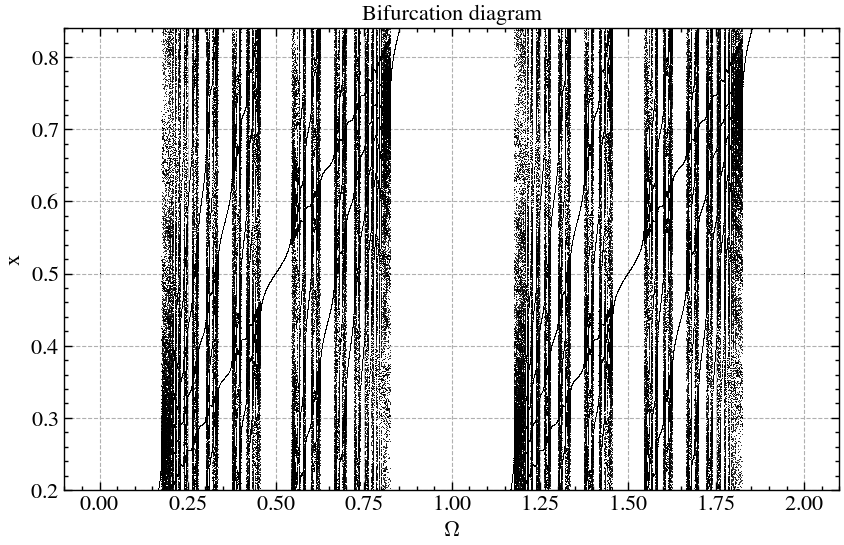

In [2]:
# Define the map
def map1(x_old, omega):
    '''
    Discrete map.
    '''
    return (x_old + omega - (1.1/(2 * np.pi)) * np.sin(2 * np.pi * x_old)) % 1.0

# Range of omega values
omega_values = np.linspace(0., 2., 10000)

# Iteration settings
n_transient = 600    # throw away these
n_keep = 300         # plot these
x0 = 0.5        # initial condition

# Lists to store points
omega_plot = []
X_plot = []

for omega in omega_values:
    # Start with initial condition
    x = x0
    
    # First iterate over the elements we'll remove
    for _ in range(n_transient):
        x = map1(x, omega)
    
    # Then, using the last x iterate for the number of elements we want to keep
    for _ in range(n_keep):
        x = map1(x, omega)
        # Append results to lists
        omega_plot.append(omega)
        X_plot.append(x)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(omega_plot, X_plot, ',k', alpha=0.8)
plt.xlabel(r'$\Omega$')
plt.ylabel('x')
#plt.xlim(-0.75, -0.5)
plt.ylim(0.2, 0.84)
plt.title(f'Bifurcation diagram')
plt.grid(True, linestyle="--", linewidth=0.8)
plt.show()

We have a repetition of the diagram every $1.0$ period, starting from $\Omega \approx 0.17$.

### b) Calculate the Lyapunov exponent as a function of $\Omega$.

To compute the Lyapunov exponent we use the formula,
$$
\lambda = \lim_{N \to \infty} \frac{1}{N} \sum_{n=0}^{N-1} \ln \left| f'(x_n) \right|.
$$
So, we need to compute the derivative of $f(x_n) = x_n + \Omega - \frac{1.1}{2\pi}\sin(2\pi x_n) \quad \text{mod}(1), \quad \text{for } x_n \in [0,1].$ 

In [3]:
# Derivative
def deriv1(x, omega):
    '''
    Derivative of the given map.
    '''
    return (1 - 1.1*np.cos(2*np.pi*x))

# Lyapunov exponent
def lyapunov(omega, x0=0.7, N=5000, transient=4000):
    '''
    Numerical Lyapunov exponent for a given omega.
    '''
    # Initial condition
    x = x0
    
    # Remove transient
    for _ in range(transient):
        x = map1(x, omega)
    
    # Compute sum
    sum_ls = 0.0
    for _ in range(N):
        # Derivative of the map
        d = deriv1(x, omega)
        # Sum
        sum_ls += np.log(abs(d + 1e-10))
        # Compute map for next iteration
        x = map1(x, omega)

    return sum_ls / N

# Compute the Lyapunov exponent
print("Computing the Lyapunov exponent...")
lyap_values = np.array([lyapunov(omega) for omega in omega_values])
print("Done.")

Computing the Lyapunov exponent...
Done.


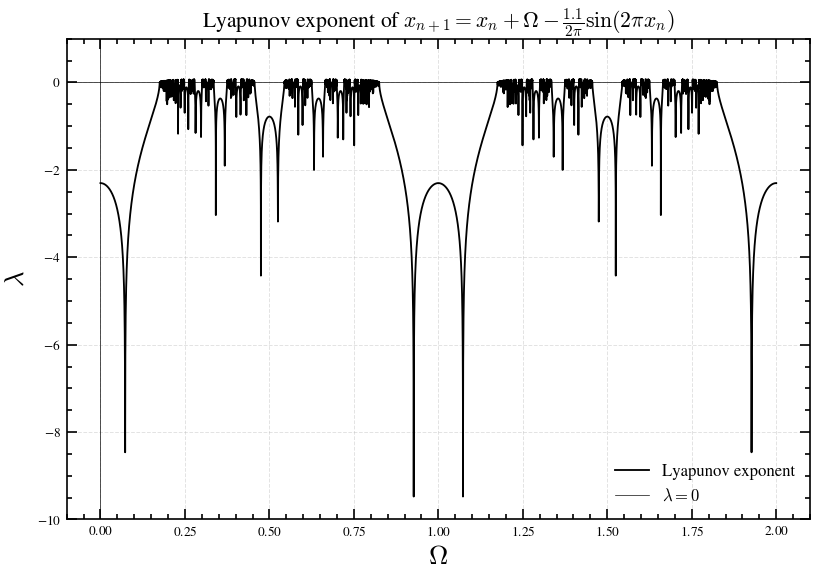

In [4]:
# Plotting
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

ax.plot(omega_values, lyap_values, color='k', linewidth=1.1, label='Lyapunov exponent')
ax.axhline(0, color='k', ls='-', lw=0.4, label=r'$\lambda = 0$')
ax.axvline(0, color='black', lw=0.4)
# Make ticks smaller
plt.tick_params(axis='both', which='major', labelsize=8)
# ax.set_xlim(1, 4)
ax.set_ylim(-10, 1)
ax.set_xlabel(r'$\Omega$', fontsize=16)
ax.set_ylabel(r'$\lambda$', fontsize=16)
ax.set_title(r'Lyapunov exponent of ' + r"$x_{n+1} = x_n + \Omega - \frac{1.1}{2\pi}\sin(2\pi x_n)$", fontsize=13)

ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.35)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


---

# 2. Consider the two-dimensional map
$$
\begin{aligned}
x_{n+1} &= 1 - a|x_n| + y_n, \\
y_{n+1} &= b x_n,
\end{aligned}
$$
where $a$ and $b$ are real parameters.

### a) By using an initial condition close to the origin $(0,0)$, plot the attractor for $a = 1.7$, $b = 0.5$. Is it a strange attractor?

In [5]:
# Define the map
def map2(x_old, y_old, a, b):
    '''
    Two-dimensional map.
    '''
    x_new = 1 - a*abs(x_old) + y_old
    y_new = b*x_old

    return x_new, y_new

# Parameters
a = 1.7
b = 0.5
n_steps = 2000

# Initial condition
x, y = 0.005, 0.005

x_vals = []
y_vals = []

# Iterations
for n in range(n_steps):
    x, y = map2(x, y, a, b)
    if n > 1000:
        x_vals.append(x)
        y_vals.append(y)

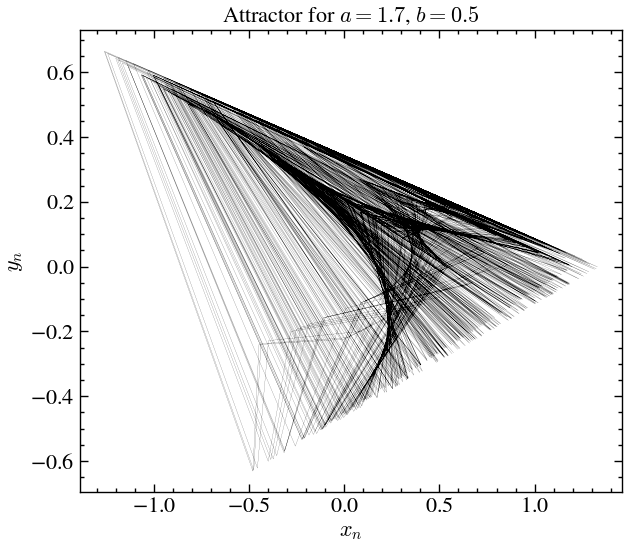

In [6]:
plt.figure(figsize=(7,6))
plt.plot(x_vals, y_vals, lw = 0.1, color='k')
plt.title(r"Attractor for $a=1.7$, $b=0.5$")
plt.xlabel(r"$x_n$")
plt.ylabel(r"$y_n$")
plt.show()

Indeed, it's a strange attractor because we can see some fractal structure.

### b) Plot the bifurcation diagram of $x_n$ as a function of $b \in [-0.7, 0.7]$, with fixed value $a = 1.5$.

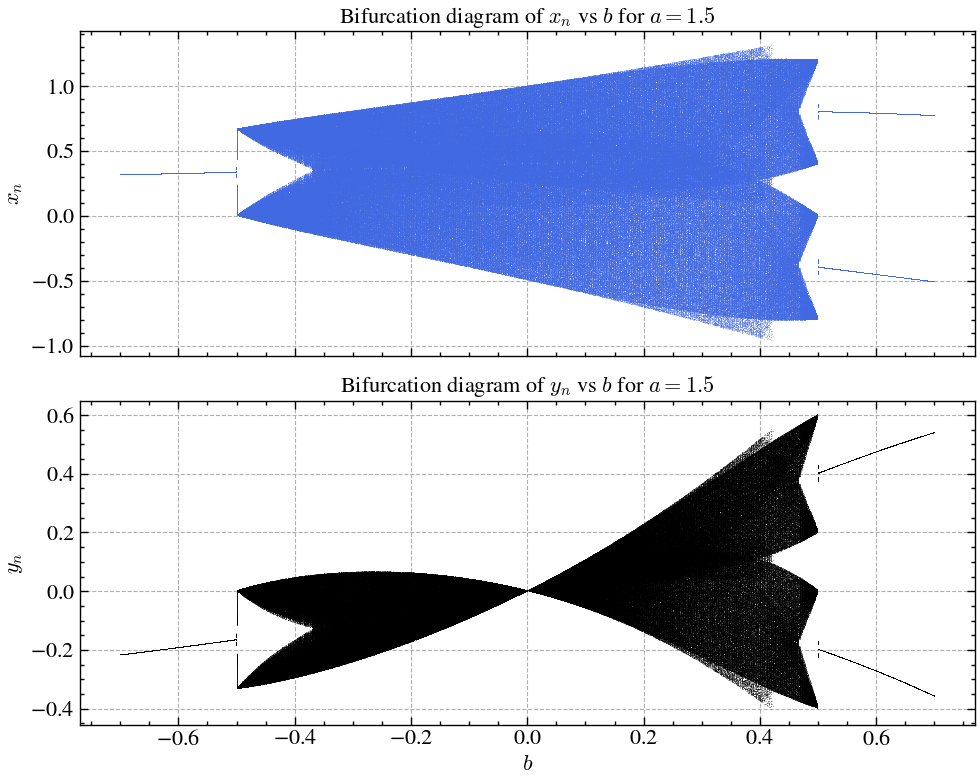

In [7]:
# Specify the new value of a
a = 1.5

# Range of b values
b_values = np.linspace(-0.7, 0.7, 2000)

# Iteration settings
n_transient = 2000    # throw away these
n_keep = 1000         # plot these
x0 = 0.005       # initial condition

# Lists to store points
B_plot = []
Y_plot = []
X_plot = []

for b in b_values:
    # Start with initial condition
    x, y = x0, x0
    
    # First iterate over the elements we'll remove
    for _ in range(n_transient):
        x, y = map2(x, y, a, b)
    # Non-transient iterations
    for _ in range(n_keep):
        x, y = map2(x, y, a, b)
        # Append results to lists
        B_plot.append(b)
        Y_plot.append(y)
        X_plot.append(x)

# Plot
# Two-panel figure
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top: x_n
axes[0].plot(B_plot, X_plot, ',', color='royalblue', alpha=0.3)
axes[0].set_ylabel(r"$x_n$")
axes[0].set_title(r"Bifurcation diagram of $x_n$ vs $b$ for $a=1.5$")
axes[0].grid(True, linestyle="--", linewidth=0.8)

# Bottom: y_n
axes[1].plot(B_plot, Y_plot, ',k', alpha=0.3)
axes[1].set_xlabel(r"$b$")
axes[1].set_ylabel(r"$y_n$")
axes[1].set_title(r"Bifurcation diagram of $y_n$ vs $b$ for $a=1.5$")
axes[1].grid(True, linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

### c) Calculate the Lyapunov exponents for this map as functions of the parameters $a$ and $b$.

In [19]:
def heatmap_lyap(
    a_min=1.0, a_max=2.0,
    b_min=0.0, b_max=1.0,
    resolution=300,
    n_iterations=1000,
    transient=2000,
    escape_bound=1e6
):
    """
    Fast vectorized computation of the Lyapunov exponent maps
    for the Lozi map:

        x_{n+1} = 1 - a|x_n| + y_n
        y_{n+1} = b x_n

    The largest Lyapunov exponent is computed directly.
    The second exponent is obtained using:

        lambda1 + lambda2 = log(|b|)

    for bounded trajectories.
    """

    # Parameter values
    a_values = np.linspace(a_min, a_max, resolution)
    b_values = np.linspace(b_min, b_max, resolution)

    # Create full parameter grid
    A, B = np.meshgrid(a_values, b_values)

    # Initial conditions for every parameter pair
    x = np.full_like(A, 0.005, dtype=float)
    y = np.full_like(A, 0.005, dtype=float)

    # Track which parameter values are still valid
    active = np.ones_like(A, dtype=bool)

    # Skip transient iterations
    for _ in range(transient):
        x_new = 1 - A * np.abs(x) + y
        y_new = B * x

        x, y = x_new, y_new

        # Mark unbounded or invalid trajectories
        escaped = (
            ~np.isfinite(x) |
            ~np.isfinite(y) |
            (np.abs(x) > escape_bound) |
            (np.abs(y) > escape_bound)
        )

        active[escaped] = False

    # Initial tangent vector for the largest exponent
    ux = np.ones_like(A, dtype=float)
    uy = np.zeros_like(A, dtype=float)

    # Accumulate logarithmic stretching
    lyap_sum = np.zeros_like(A, dtype=float)

    # Main Lyapunov loop
    for _ in range(n_iterations):

        # Derivative of the first component with respect to x
        # For x >= 0: df1/dx = -a
        # For x < 0:  df1/dx = a
        dfdx = np.where(x >= 0, -A, A)

        # Apply the Jacobian to the tangent vector
        ux_new = dfdx * ux + uy
        uy_new = B * ux

        # Norm of the evolved tangent vector
        norm = np.sqrt(ux_new**2 + uy_new**2)

        # Valid points must still be active and have nonzero finite norm
        valid = active & np.isfinite(norm) & (norm > 0)

        # Accumulate log stretching only for valid points
        lyap_sum[valid] += np.log(norm[valid])

        # Normalize tangent vector
        ux[valid] = ux_new[valid] / norm[valid]
        uy[valid] = uy_new[valid] / norm[valid]

        # Evolve the Lozi map
        x_new = 1 - A * np.abs(x) + y
        y_new = B * x

        x, y = x_new, y_new

        # Check for escape or numerical overflow
        escaped = (
            ~np.isfinite(x) |
            ~np.isfinite(y) |
            (np.abs(x) > escape_bound) |
            (np.abs(y) > escape_bound)
        )

        active[escaped] = False

    # Largest Lyapunov exponent
    lambda1_map = lyap_sum / n_iterations

    # Invalid/unbounded trajectories are marked as NaN
    lambda1_map[~active] = np.nan

    # Second exponent from determinant relation:
    # lambda1 + lambda2 = log(|b|)
    lambda2_map = np.full_like(lambda1_map, np.nan)

    nonzero_b = active & (np.abs(B) > 0)
    lambda2_map[nonzero_b] = np.log(np.abs(B[nonzero_b])) - lambda1_map[nonzero_b]

    # For b = 0, det(J) = 0, so the second exponent formally goes to -infinity
    zero_b = active & (np.abs(B) == 0)
    lambda2_map[zero_b] = -np.inf

    print("Done!")

    return lambda1_map, lambda2_map, a_values, b_values

# # Call the function
# lambda1_map, lambda2_map, a_values, b_values = heatmap_lyap(
#     a_min=1.0, a_max=2.0,
#     b_min=0.0, b_max=1.0,
#     resolution=350,
#     n_iterations=2000,
#     transient=2000
# )

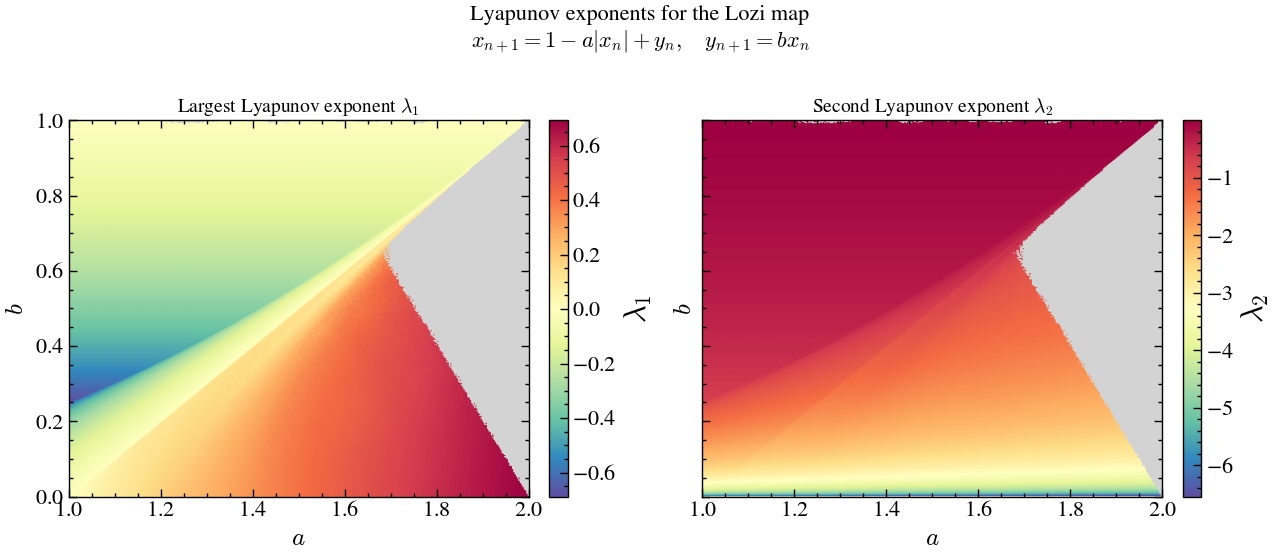

In [9]:
#Plotting
# Copies for plotting
lambda1_plot = lambda1_map.copy()
lambda2_plot = lambda2_map.copy()

# Replace infinities with NaN so they appear as missing values
lambda1_plot[~np.isfinite(lambda1_plot)] = np.nan
lambda2_plot[~np.isfinite(lambda2_plot)] = np.nan

# Colormap with NaN regions in light gray
cmap = plt.cm.Spectral_r.copy()
cmap.set_bad(color="lightgray")

# Create horizontal subplot layout
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)

# First plot: lambda_1
im1 = axes[0].imshow(
    lambda1_plot,
    extent=[a_values[0], a_values[-1], b_values[0], b_values[-1]],
    aspect="auto",
    origin="lower",
    cmap=cmap
)

axes[0].set_title(r"Largest Lyapunov exponent $\lambda_1$", fontsize=14)
axes[0].set_xlabel(r"$a$", fontsize=18)
axes[0].set_ylabel(r"$b$", fontsize=18)

cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label(r"$\lambda_1$", fontsize=22)

# Second plot: lambda_2
im2 = axes[1].imshow(
    lambda2_plot,
    extent=[a_values[0], a_values[-1], b_values[0], b_values[-1]],
    aspect="auto",
    origin="lower",
    cmap=cmap
)

axes[1].set_title(r"Second Lyapunov exponent $\lambda_2$", fontsize=14)
axes[1].set_xlabel(r"$a$", fontsize=18)
axes[1].set_ylabel(r"$b$", fontsize=18)

cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label(r"$\lambda_2$", fontsize=22)

# Main title
fig.suptitle(
    r"Lyapunov exponents for the Lozi map" + "\n" +
    r"$x_{n+1}=1-a|x_n|+y_n,\quad y_{n+1}=bx_n$",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

Grey regions correspond to parameter values where the orbit is unbounded, trajectories have escaped.

### d) Calculate the fractal dimension of the attractor for $a = 1.7$, $b = 0.5$.

We use the Kaplan-Yorke formula. We have two cases $x < 0$ and $x > 0$, but they both yield the same result.

The Jacobian matrix is given by,
$$
J = \begin{pmatrix}
-1.7 & 1 \\
0.5 & 0
\end{pmatrix}
$$
Then, we compute its eigenvalues.

In [10]:
# Define the Jacobian
J = np.array([[-1.7, 1],
              [0.5, 0]])
# Compute the eigenvalues
eigenvalues, _ = np.linalg.eig(J)

print("Eigenvalues (m): " + ", ".join(f"{v:.4f}" for v in eigenvalues))
# print(np.log(0.2557))
# print(np.log(1.9557))
#print(1 + 0.6707/1.3638)

Eigenvalues (m): -1.9557, 0.2557


We can now compute the Lyapunov exponents $(\lambda)$.
$$
\Rightarrow e^{\lambda} = m,
$$
$$
\lambda = ln|m|,
$$
$$
\lambda_1 = ln(1.9557) \approx 0.6707,
$$
$$
\lambda_2 = ln(0.2557) \approx -1.3638.
$$

These values correspond to our plots!

Since $\lambda_2 < 0$ and $\lambda_1 > 0$, the fractal dimension is computed as,
$$
D = 1 + \frac{\lambda_1}{|\lambda_2|} \approx 1.49.
$$

---

# 3. Consider the map defined for $x_n \in [0,1]$,

$$
x_{n+1}=\frac{a}{2}\left(1-\left|1-2x_n\right|\right).
$$

### a) Show that different initial conditions $x_0$ escape the interval $[0,1]$ for $a=2+\epsilon$.

In [11]:
# Define epsilon
eps = 1e-2
# Define the value of a
a = 2 + eps
# Define the map
def map3(x_old, a):
    '''
    Discrete map 3.
    '''
    return (a/2) * (1 - abs(1 - 2*x_old))
# ICs
initial_conditions = np.linspace(0, 1, 101)
# Iterations
iterations = 500

for x0 in initial_conditions:
    # Set initial condition
    x = x0
    # Compute the map
    for i in range(1, iterations + 1):
        x = map3(x, a)
        # Print if escaped the domain
        if x > 1:
            print(f"x0 = {x0:.3f} escaped at iteration {i}, x = {x:.6f}")
            break

x0 = 0.010 escaped at iteration 121, x = 1.000765
x0 = 0.020 escaped at iteration 29, x = 1.003689
x0 = 0.030 escaped at iteration 344, x = 1.003833
x0 = 0.040 escaped at iteration 180, x = 1.001270
x0 = 0.050 escaped at iteration 474, x = 1.001373
x0 = 0.070 escaped at iteration 211, x = 1.000039
x0 = 0.080 escaped at iteration 100, x = 1.002958
x0 = 0.090 escaped at iteration 161, x = 1.004630
x0 = 0.110 escaped at iteration 115, x = 1.000061
x0 = 0.120 escaped at iteration 55, x = 1.002313
x0 = 0.130 escaped at iteration 466, x = 1.001152
x0 = 0.140 escaped at iteration 114, x = 1.004725
x0 = 0.150 escaped at iteration 27, x = 1.004315
x0 = 0.160 escaped at iteration 96, x = 1.004237
x0 = 0.180 escaped at iteration 29, x = 1.001728
x0 = 0.190 escaped at iteration 397, x = 1.000918
x0 = 0.200 escaped at iteration 95, x = 1.000675
x0 = 0.210 escaped at iteration 118, x = 1.000379
x0 = 0.230 escaped at iteration 32, x = 1.003998
x0 = 0.240 escaped at iteration 230, x = 1.003361
x0 = 0.

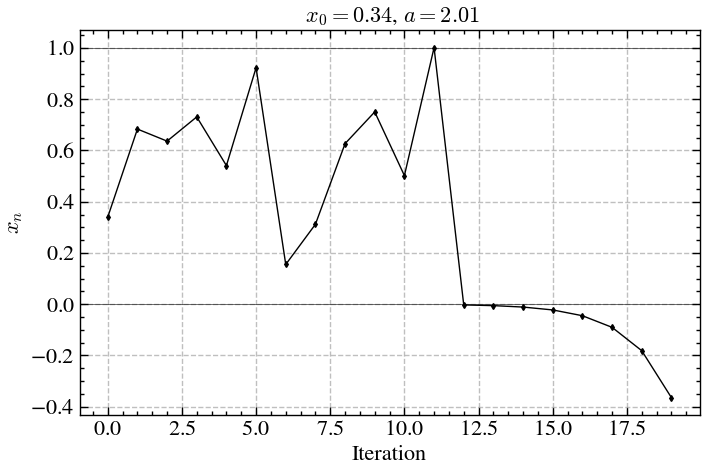

In [12]:
# Plotting one orbit that escaped
x0 = 0.340
orbit = [x0]

x = x0
for i in range(1, iterations + 1):
    x = map3(x, a)
    orbit.append(x)

plt.figure(figsize=(8, 5))
plt.plot(orbit[:20], marker="d", markersize=3, c='k', alpha=1.0, lw=1.0)
plt.axhline(0, color='black', lw=0.4)
plt.axhline(1, color='black', lw=0.4)

plt.xlabel("Iteration")
plt.ylabel(r"$x_n$")
plt.title(rf" $x_0={x0}$, $a={a}$")

plt.grid(True, linestyle="--", alpha=0.8)
plt.show()

### b) Calculate the fractal dimension of the repeller set for $a=2+\epsilon$, as a function of $\epsilon$.

$$
\boxed{
D_f(\epsilon)=\frac{\log 2}{\log(a)}
}
$$

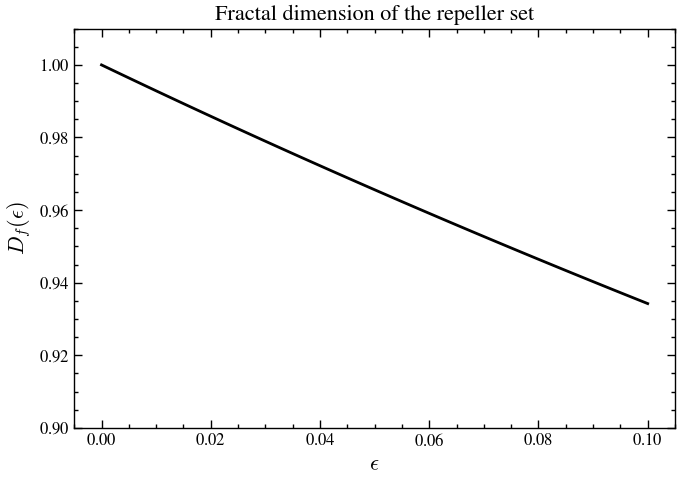

In [13]:
# Epsilon values
epsilon_values = np.linspace(0.00, 0.1, 50)

# Exact fractal dimension
dimensions = np.log(2) / np.log(2 + epsilon_values)

# Plot
plt.figure(figsize=(7, 5))

plt.plot(epsilon_values, dimensions, color="black", linewidth=2)

plt.xlabel(r"$\epsilon$", fontsize=16)
plt.ylabel(r"$D_f(\epsilon)$", fontsize=16)
plt.title(r"Fractal dimension of the repeller set", fontsize=16)

plt.ylim(0.9, 1.01)
plt.tick_params(axis="both", which="major", labelsize=12)

plt.tight_layout()
plt.show()

---

# 4. The logarithmic map

$$
x_{n+1}=b+\log|x_n|
$$

exhibits robust chaos in the parameter interval $b\in[0,1]$.

### a) Calculate the unstable fixed point for $b=0$.
$$
x^* - \ln|x^*| = 0.
$$

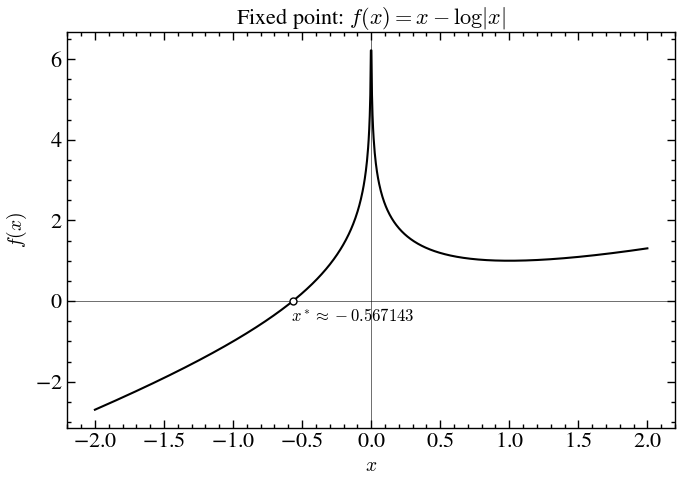

In [14]:
# Map
def map4(x, b=0):
    """
    Discrete map.
    """
    return b + np.log(np.abs(x))
# Get fixed point
def fixed_point(x, b=0):
    """
    Fixed point map.
    """
    return x - map4(x, b)
# Compute the fixed point
# x values
x_arr = np.linspace(-2, 2, 1000)

# Function of the fixed point (its roots are what concerns us)
y = fixed_point(x_arr, b=0)

plt.figure(figsize=(7, 5))
plt.title("Fixed point: " + r"$f(x) = x - \log|x|$", fontsize=16)
plt.plot(x_arr, y, lw=1.5, c='k')
plt.xlabel(r'$x$', fontsize=14)
plt.ylabel(r'$f(x)$', fontsize=14)
plt.axhline(0, color='black', lw=0.4)
plt.axvline(0, color='black', lw=0.4)

# Point of intersection
plt.plot(-0.567143, 0, 'wo', markersize=5, markeredgecolor='black')
plt.text(-0.58, -0.5, r"$x^* \approx -0.567143$", fontsize=12, color='black', weight='bold')
plt.tight_layout()
plt.show()

It's untable because $|f'(x^*)| > 1$.

### b) Use the GOY method for controlling chaos to stabilize the fixed point at $b=0$. Show the time series of $x_n$ before and after the control is applied.

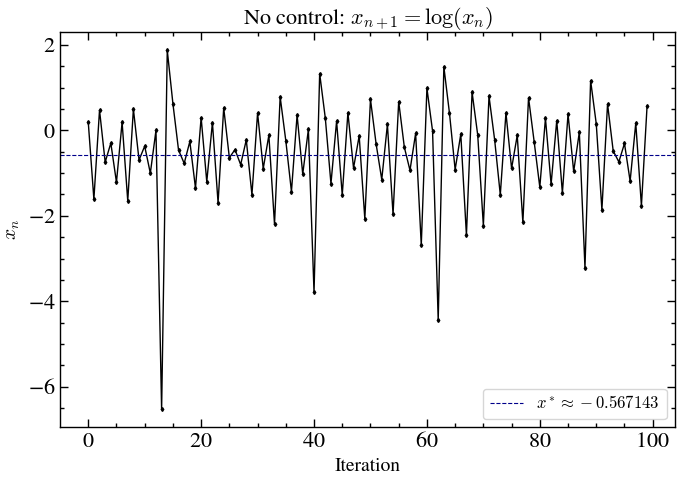

In [15]:
# Set b
b = 0

# Number of iterations
n_iterations = 100

# Initialize array
x_values = np.zeros(n_iterations)

# Set initial condition
x_values[0] = 0.2

# Iterate
for i in range(1, n_iterations):
    x_values[i] = map4(x_values[i-1], b)
    
#Plotting
plt.figure(figsize=(7, 5))
plt.title("No control: "+ r'$x_{n+1} = \log(x_n)$', fontsize=16) # we're just considering positive values

plt.plot(range(n_iterations), x_values, markersize=2, c='k', alpha=1.0, lw=1.0, marker ='d')

plt.xlabel("Iteration", fontsize=14)
plt.ylabel(r'$x_n$', fontsize=14)

plt.axhline(-0.567143, color='darkblue', lw=0.8, label =r"$x^* \approx -0.567143$", ls ='--')
plt.legend(fontsize=12, frameon=True, loc='lower right')
plt.tight_layout()
plt.show()

In [16]:
# With control
def map4_control(x, b, eps, control_param, unstable_fpnt):
    """
    Map with control.
    """
    # Compute the next value
    x_new = b + np.log(np.abs(x))
    
    # Apply control if iteration is close enough to the unstable fixed point
    if abs(x_new - unstable_fpnt) < eps:
        x_new += control_param * (unstable_fpnt - x_new)
    
    return x_new

In [17]:
# Initialize array
x_vals = np.zeros(n_iterations)

# Set initial condition
x_vals[0] = 0.2

# Iterate
for i in range(1, n_iterations):
    x_vals[i] = map4_control(x_vals[i-1], b, eps=0.1, control_param=0.8, unstable_fpnt=-0.56714)

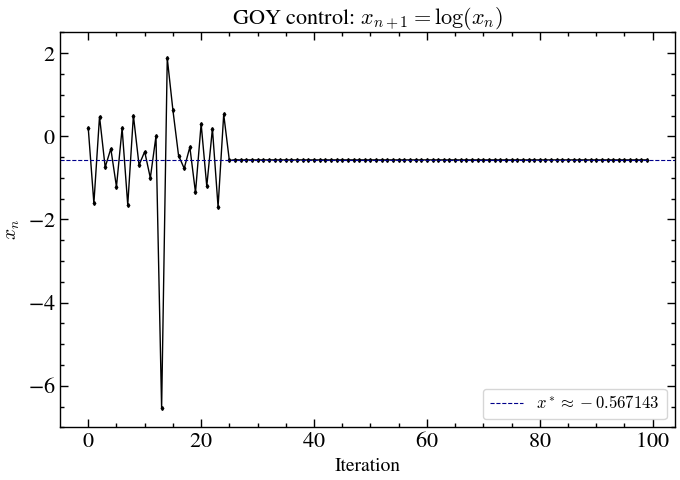

In [18]:
# Plotting
plt.figure(figsize=(7, 5))

plt.title("GOY control: " + r'$x_{n+1} = \log(x_n)$', fontsize=16)
plt.plot(range(n_iterations), x_vals, markersize=2, c='k', alpha=1.0, lw=1.0, marker ='d')

plt.xlabel("Iteration", fontsize=14)
plt.ylabel(r'$x_n$', fontsize=14)

plt.ylim(-7, 2.5)
plt.axhline(-0.567143, color='darkblue', lw=0.8, label =r"$x^* \approx -0.567143$", ls ='--')
plt.legend(fontsize=12, frameon=True, loc='lower right')
plt.tight_layout()
plt.show()